# Exploratory Data Analysis — Face Occlusion Dataset

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")
%matplotlib inline

DATA_ROOT = "../data/raw"
IMAGE_DIR = os.path.join(DATA_ROOT, "Crop_224_5fp_100K")

df_train = pd.read_csv(os.path.join(DATA_ROOT, "train.csv")).dropna()
df_test = pd.read_csv(os.path.join(DATA_ROOT, "test_students.csv")).dropna()
print(f"Train: {len(df_train)} samples, Test: {len(df_test)} samples")
df_train.head()

Train: 100000 samples, Test: 29980 samples


,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


## 1. Basic Statistics

In [4]:
print("=== Train Set ===")
print(f"Total samples: {len(df_train)}")
print(f"Missing values:\n{df_train.isnull().sum()}")
print(f"\nGender split (1.0=M, 0.0=F):")
print(df_train["gender"].value_counts())
print(f"\nOcclusion stats:")
print(df_train["FaceOcclusion"].describe())

=== Train Set ===
Total samples: 100000
Missing values:
filename         0
FaceOcclusion    0
gender           0
dtype: int64

Gender split (1.0=M, 0.0=F):
gender
1.0    67600
0.0    32400
Name: count, dtype: int64

Occlusion stats:
count    100000.000000
mean          0.082720
std           0.086538
min           0.000000
25%           0.017928
50%           0.049661
75%           0.122675
max           1.000000
Name: FaceOcclusion, dtype: float64


## 2. Occlusion Distribution

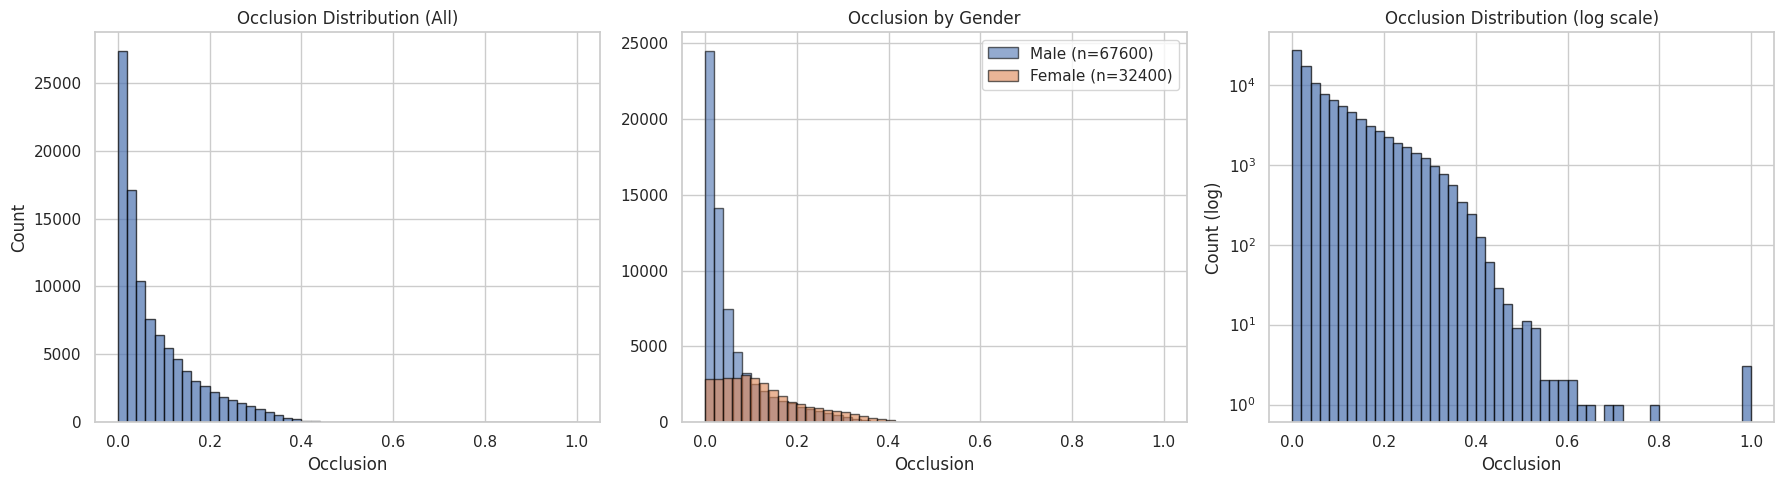

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall
axes[0].hist(df_train["FaceOcclusion"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Occlusion Distribution (All)")
axes[0].set_xlabel("Occlusion")
axes[0].set_ylabel("Count")

# By gender
df_m = df_train[df_train["gender"] == 1.0]
df_f = df_train[df_train["gender"] == 0.0]

axes[1].hist(df_m["FaceOcclusion"], bins=50, alpha=0.6, label=f"Male (n={len(df_m)})", edgecolor="black")
axes[1].hist(df_f["FaceOcclusion"], bins=50, alpha=0.6, label=f"Female (n={len(df_f)})", edgecolor="black")
axes[1].set_title("Occlusion by Gender")
axes[1].set_xlabel("Occlusion")
axes[1].legend()

# Log scale
axes[2].hist(df_train["FaceOcclusion"], bins=50, edgecolor="black", alpha=0.7)
axes[2].set_yscale("log")
axes[2].set_title("Occlusion Distribution (log scale)")
axes[2].set_xlabel("Occlusion")
axes[2].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()

## 3. Occlusion Bins

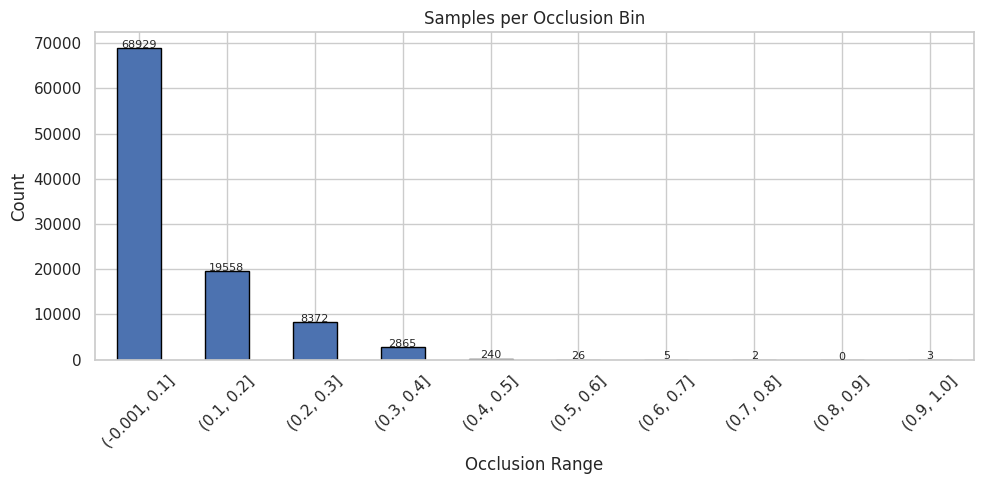

In [6]:
bins = np.arange(0, 1.1, 0.1)
df_train["occ_bin"] = pd.cut(df_train["FaceOcclusion"], bins=bins, include_lowest=True)
bin_counts = df_train["occ_bin"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bin_counts.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("Samples per Occlusion Bin")
ax.set_xlabel("Occlusion Range")
ax.set_ylabel("Count")
for i, v in enumerate(bin_counts):
    ax.text(i, v + 50, str(v), ha="center", fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_train.drop(columns=["occ_bin"], inplace=True)

## 4. Sample Visualization (16 Random Images)

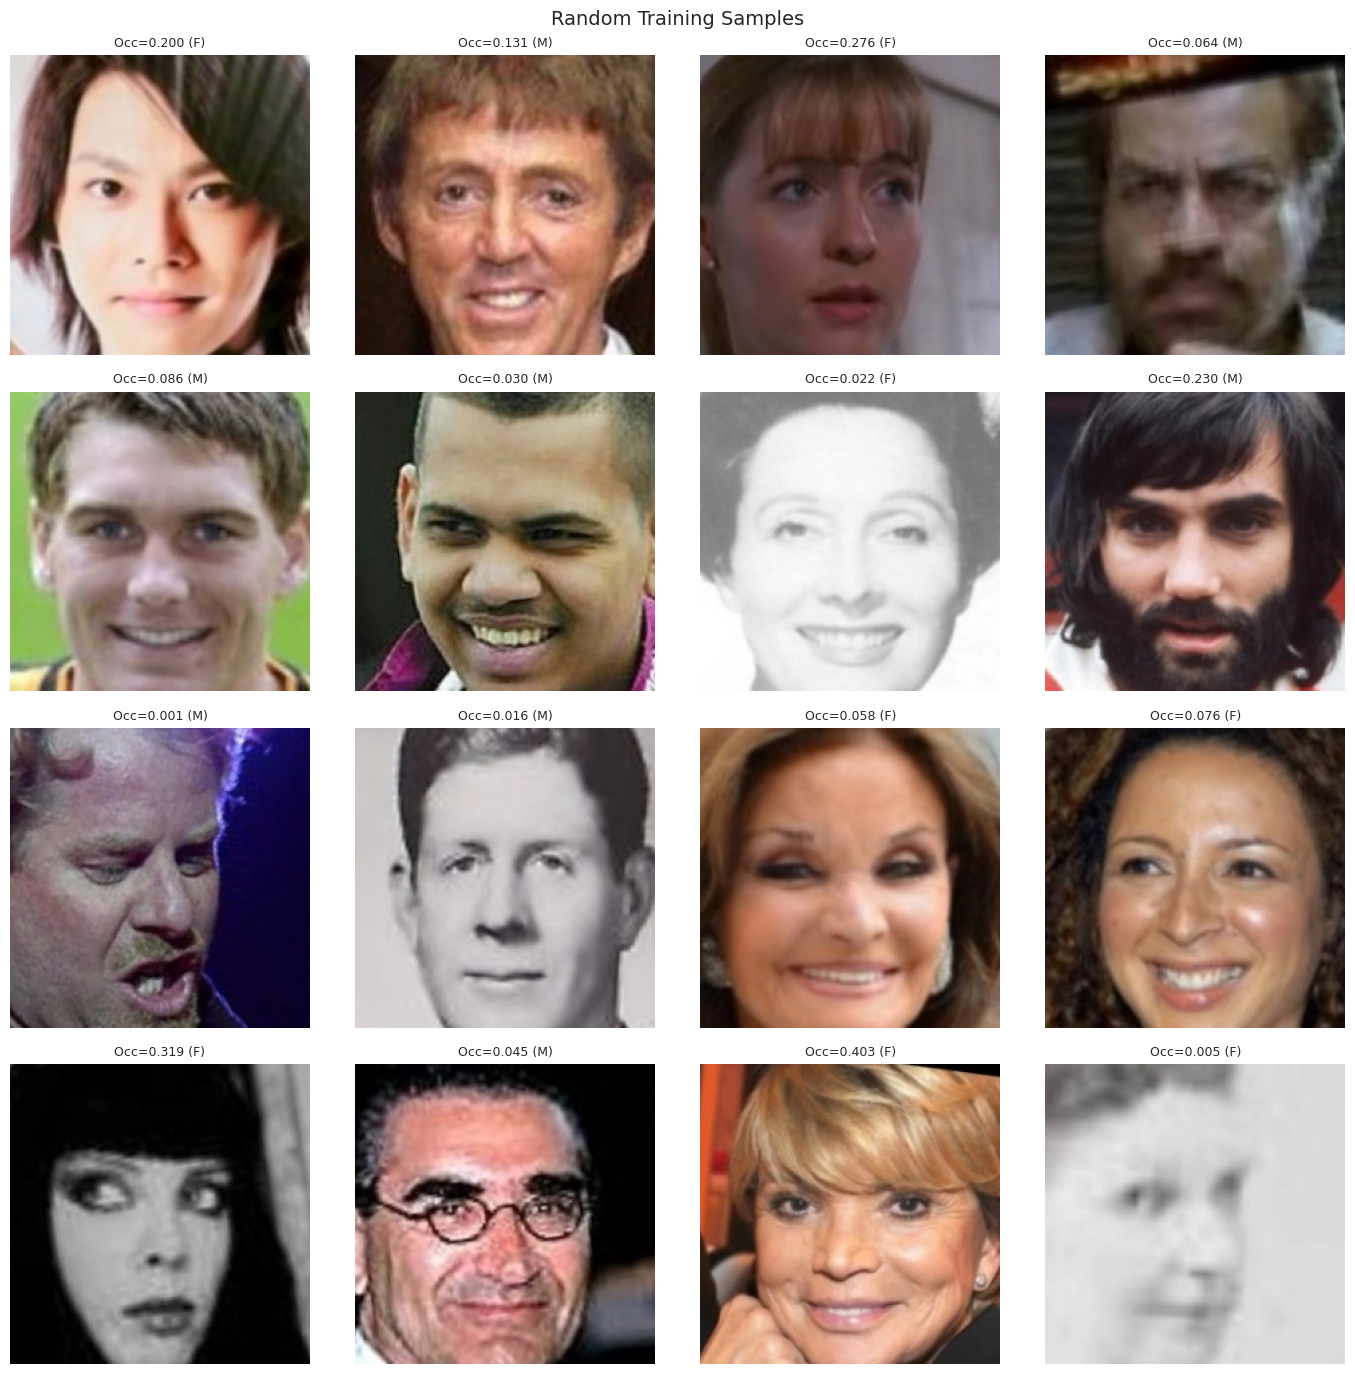

In [7]:
sample = df_train.sample(16, random_state=42)
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = Image.open(os.path.join(IMAGE_DIR, row["filename"]))
    ax.imshow(img)
    gender_str = "M" if row["gender"] == 1.0 else "F"
    ax.set_title(f"Occ={row['FaceOcclusion']:.3f} ({gender_str})", fontsize=9)
    ax.axis("off")
plt.suptitle("Random Training Samples", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Extreme Cases: Least and Most Occluded

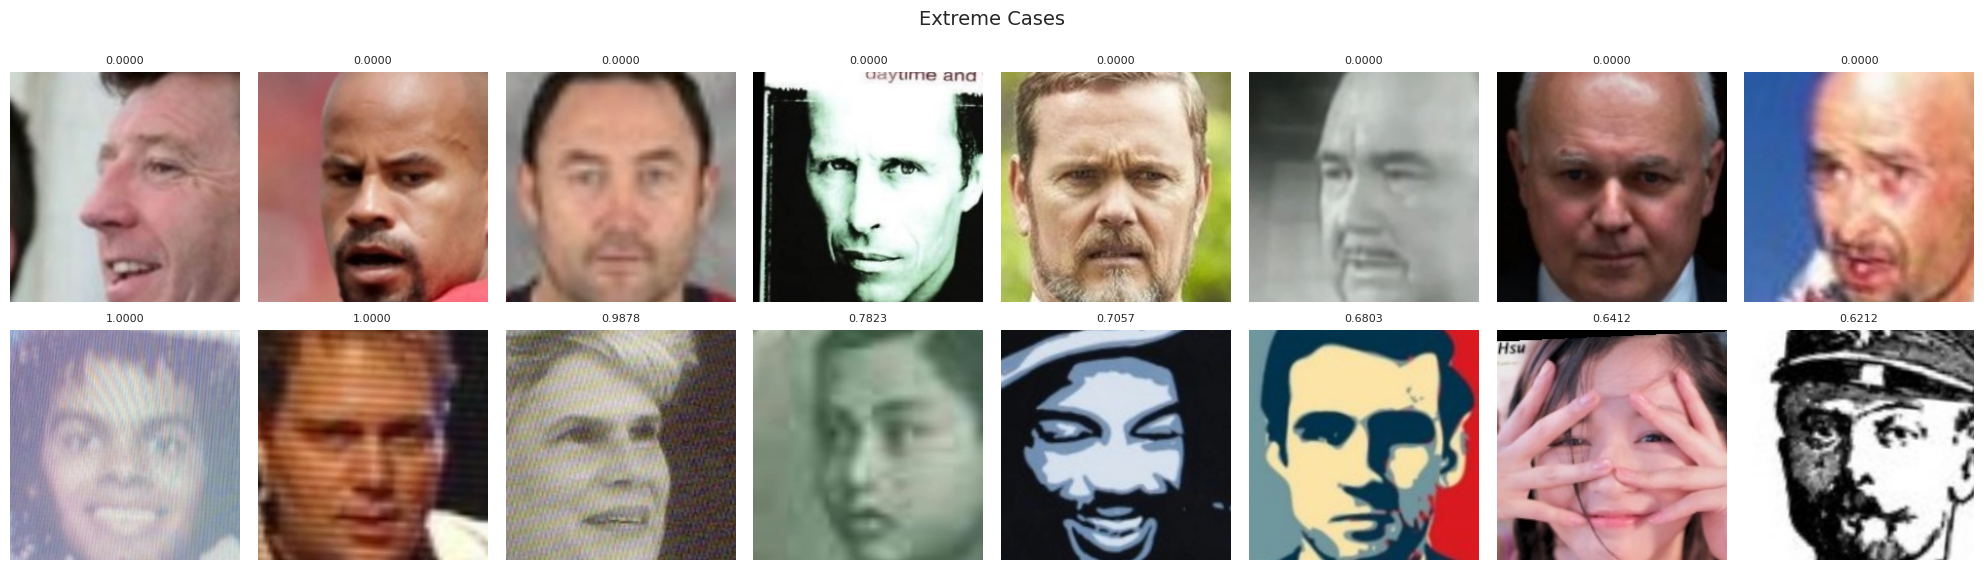

In [8]:
least_occ = df_train.nsmallest(8, "FaceOcclusion")
most_occ = df_train.nlargest(8, "FaceOcclusion")

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for ax, (_, row) in zip(axes[0], least_occ.iterrows()):
    img = Image.open(os.path.join(IMAGE_DIR, row["filename"]))
    ax.imshow(img)
    ax.set_title(f"{row['FaceOcclusion']:.4f}", fontsize=8)
    ax.axis("off")
axes[0, 0].set_ylabel("Least Occluded", fontsize=11)

for ax, (_, row) in zip(axes[1], most_occ.iterrows()):
    img = Image.open(os.path.join(IMAGE_DIR, row["filename"]))
    ax.imshow(img)
    ax.set_title(f"{row['FaceOcclusion']:.4f}", fontsize=8)
    ax.axis("off")
axes[1, 0].set_ylabel("Most Occluded", fontsize=11)

plt.suptitle("Extreme Cases", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Per-Database Statistics

Samples per database:
database
database3    96023
database1     3747
database2      230
Name: count, dtype: int64


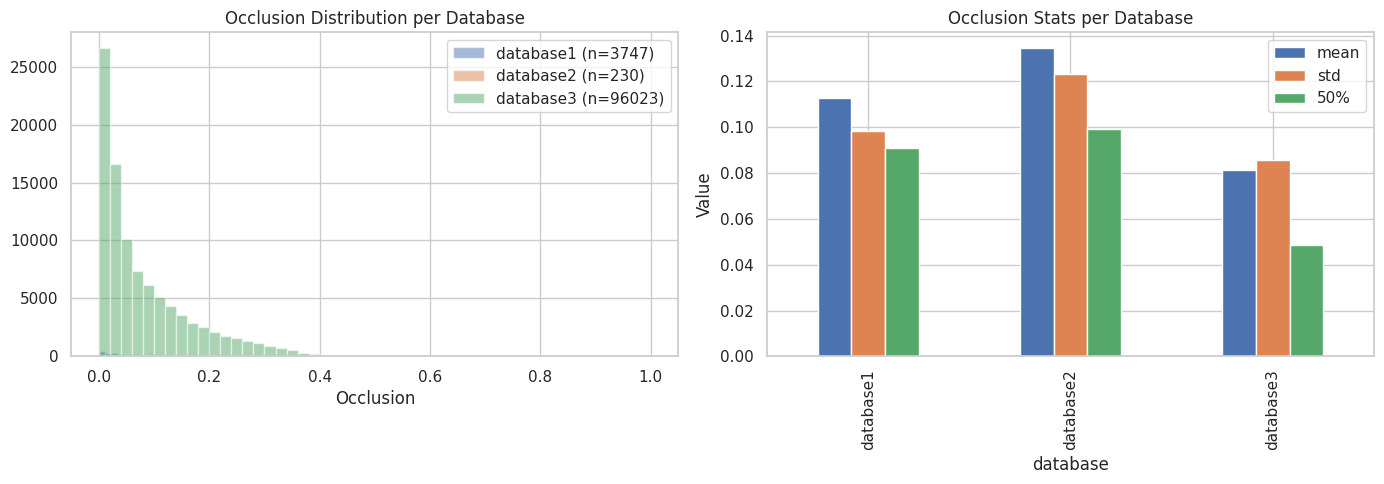

In [9]:
df_train["database"] = df_train["filename"].str.split("/").str[0]

print("Samples per database:")
print(df_train["database"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for db in sorted(df_train["database"].unique()):
    subset = df_train[df_train["database"] == db]
    axes[0].hist(subset["FaceOcclusion"], bins=50, alpha=0.5, label=f"{db} (n={len(subset)})")
axes[0].set_title("Occlusion Distribution per Database")
axes[0].set_xlabel("Occlusion")
axes[0].legend()

db_stats = df_train.groupby("database")["FaceOcclusion"].describe()
db_stats[["mean", "std", "50%"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Occlusion Stats per Database")
axes[1].set_ylabel("Value")
plt.tight_layout()
plt.show()

df_train.drop(columns=["database"], inplace=True)

## 7. Weight Analysis

Weight range: [0.0333, 1.0333]
Max/Min weight ratio: 31.0x
Samples with GT > 0.5 get weight > 0.533 (vs min 0.0333)


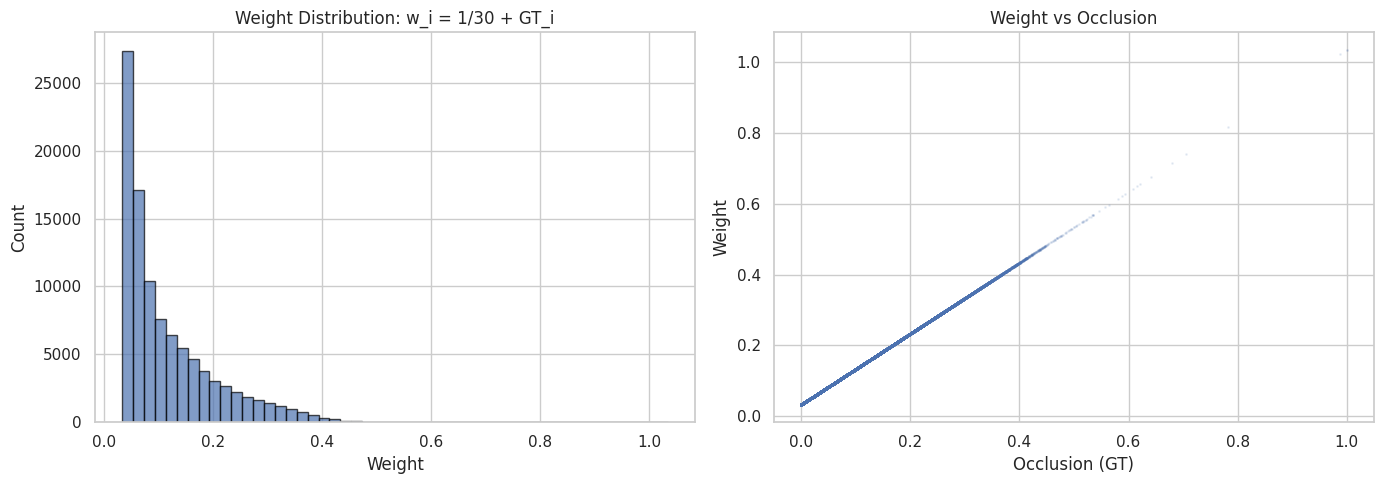

In [10]:
weights = 1.0 / 30.0 + df_train["FaceOcclusion"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(weights, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Weight Distribution: w_i = 1/30 + GT_i")
axes[0].set_xlabel("Weight")
axes[0].set_ylabel("Count")

axes[1].scatter(df_train["FaceOcclusion"], weights, alpha=0.1, s=1)
axes[1].set_title("Weight vs Occlusion")
axes[1].set_xlabel("Occlusion (GT)")
axes[1].set_ylabel("Weight")

print(f"Weight range: [{weights.min():.4f}, {weights.max():.4f}]")
print(f"Max/Min weight ratio: {weights.max() / weights.min():.1f}x")
print(f"Samples with GT > 0.5 get weight > {1/30 + 0.5:.3f} (vs min {1/30:.4f})")

plt.tight_layout()
plt.show()

## 8. Test Set Analysis

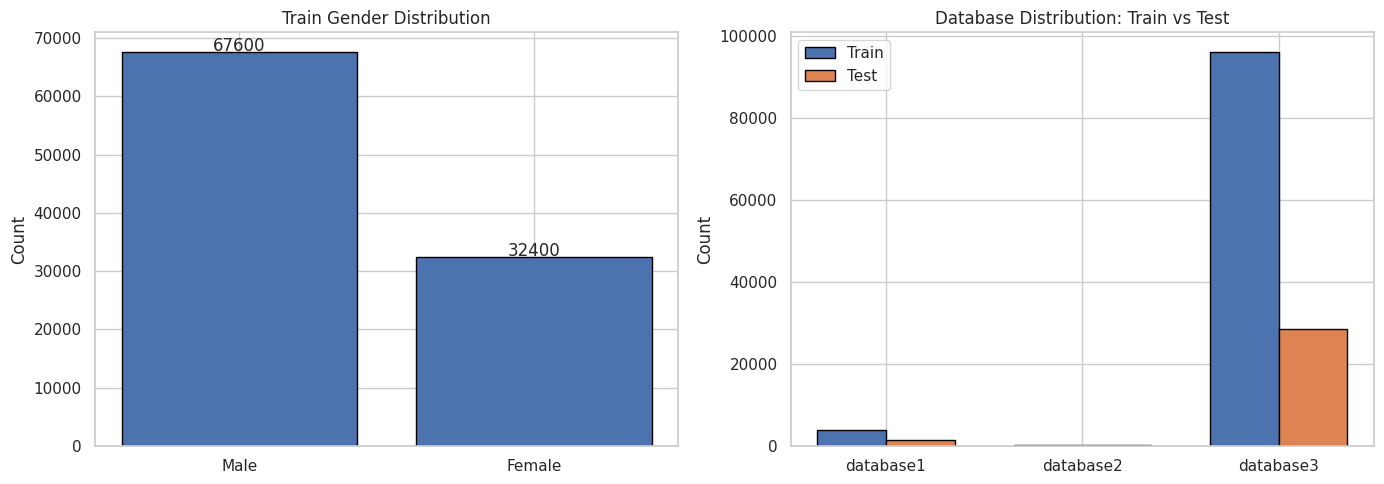

Test set has 29980 samples
Test database distribution:
database
database1     1427
database2      118
database3    28435
Name: count, dtype: int64


In [11]:
df_test["database"] = df_test["filename"].str.split("/").str[0]
df_train_tmp = df_train.copy()
df_train_tmp["database"] = df_train_tmp["filename"].str.split("/").str[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender distribution comparison (train only, test has no gender)
gender_counts = df_train_tmp["gender"].value_counts().rename({1.0: "Male", 0.0: "Female"})
axes[0].bar(["Male", "Female"], gender_counts.values, edgecolor="black")
axes[0].set_title("Train Gender Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 100, str(v), ha="center")

# Database distribution comparison
train_db = df_train_tmp["database"].value_counts().sort_index()
test_db = df_test["database"].value_counts().sort_index()
x = np.arange(len(train_db))
width = 0.35
axes[1].bar(x - width/2, train_db.values, width, label="Train", edgecolor="black")
axes[1].bar(x + width/2, test_db.reindex(train_db.index, fill_value=0).values, width, label="Test", edgecolor="black")
axes[1].set_xticks(x)
axes[1].set_xticklabels(train_db.index)
axes[1].set_title("Database Distribution: Train vs Test")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Test set has {len(df_test)} samples")
print(f"Test database distribution:\n{test_db}")

df_test.drop(columns=["database"], inplace=True)